=== Distance-only linear fit (1/u vs 1/v) ===
Measured slope = -0.1357 (ideal = -1)
Intercept = -0.025607  => f = -39.0520 cm
R^2 = 0.9485

=== Combined fit (using magnification) ===
Best-fit f = 8.4482 cm
Objective (combined normalized chi-sum) = 3150.41


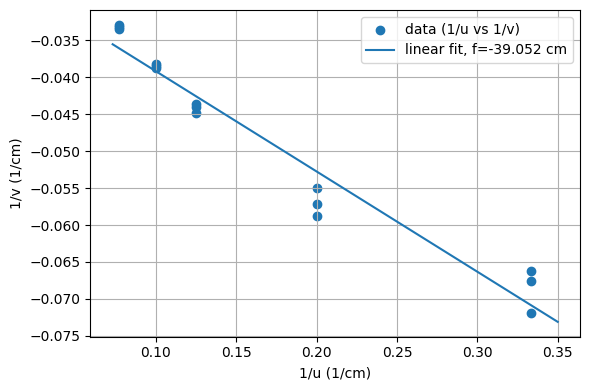

In [45]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import linregress
import matplotlib.pyplot as plt

# --- Data (your provided values) ---
data = {
    60.0: [(45.2, 12.0), (46.1, 12.3), (44.9, 11.9)],
    62.0: [(43.8, 11.5), (44.5, 11.7), (45.0, 11.8)],
    65.0: [(42.1, 10.9), (42.7, 11.0), (42.3, 10.8)],
    67.0: [(40.8, 10.5), (41.2, 10.6), (41.0, 10.4)],
    70.0: [(39.6, 9.8),  (40.1, 9.9),  (39.9, 9.7)],
}

# --- User settings ---
# If you KNOW the absolute object position (cm), set it here.
# If unknown and you want to fit it from magnification data, set to None.
object_pos_cm = 57.0        # e.g., 0.0  (set None if you want to fit it)
object_size_mm = 10      # e.g., 25.0 (mm). Set None if you don't have object size.

# --- Build arrays ---
lens_pos_list = []
screen_pos_list = []
img_size_mm_list = []

for lens_pos, trials in data.items():
    for screen_pos, img_size in trials:
        lens_pos_list.append(lens_pos)
        screen_pos_list.append(screen_pos)
        img_size_mm_list.append(img_size)

lens_pos = np.array(lens_pos_list)       # cm
screen_pos = np.array(screen_pos_list)   # cm
img_size_mm = np.array(img_size_mm_list) # mm

# If object_pos is known, compute u and v directly
def compute_u_v(object_pos):
    u = lens_pos - object_pos     # object distance (cm)
    v = screen_pos - lens_pos     # image distance (cm)
    return u, v

# ----------------------
# Mode A: Distance-only linear fit (stable)
# 1/v = -1/u + 1/f  --> y = slope*x + intercept  with slope ~ -1, intercept = 1/f
# ----------------------
u_vals, v_vals = compute_u_v(object_pos_cm if object_pos_cm is not None else 0.0)
x = 1.0 / u_vals
y = 1.0 / v_vals

slope, intercept, r_value, p_value, stderr = linregress(x, y)
f_from_linear = 1.0 / intercept

print("=== Distance-only linear fit (1/u vs 1/v) ===")
print(f"Measured slope = {slope:.4f} (ideal = -1)")
print(f"Intercept = {intercept:.6f}  => f = {f_from_linear:.4f} cm")
print(f"R^2 = {r_value**2:.4f}")
print()

# ----------------------
# Mode B: Combined fit using distances + magnification (optional)
# If object_size_mm is provided, we can add magnification residuals:
#   measured m = image_size_mm / object_size_mm  (unitless)
#   predicted m = v/u
# We will optionally fit f and (optionally) object_pos if it was set to None.
# ----------------------
def chi2_params(params, fit_object_pos):
    # params: [f] or [f, object_pos]
    f = params[0]
    if fit_object_pos:
        object_pos = params[1]
    else:
        object_pos = object_pos_cm if object_pos_cm is not None else 0.0

    # avoid non-physical f or u-f~0
    if f <= 0 or np.any(lens_pos - object_pos <= f*1e-6):
        return 1e12

    u, v = compute_u_v(object_pos)
    # model relation in 1/v space
    model_y = -1.0 / u + 1.0 / f
    resid_y = (1.0 / v) - model_y

    # normalized chi2 for distance part (no measurement uncertainties given)
    chi_y = np.sum(resid_y**2) / (len(resid_y)-1)

    chi_m = 0.0
    if object_size_mm is not None:
        m_meas = img_size_mm / object_size_mm  # unitless
        m_pred = v / u
        # Normalize magnification residuals by their standard deviation to roughly balance scales
        sigma_m = np.std(m_meas) if np.std(m_meas) > 0 else 1.0
        resid_m = (m_meas - m_pred) / sigma_m
        chi_m = np.sum(resid_m**2) / (len(resid_m)-1)
        # combine equally:
        chi_total = chi_y + chi_m
    else:
        chi_total = chi_y

    return chi_total

# Decide which parameters to fit
if object_size_mm is not None and object_pos_cm is None:
    # fit both f and object_pos
    x0 = [f_from_linear, 0.0]   # initial guesses: f from linear, object_pos guess 0 cm
    bounds = [(1e-3, 1000.0), (-1000.0, min(lens_pos)-0.1)]
    fit_object_pos = True
elif object_size_mm is not None and object_pos_cm is not None:
    # fit only f, fix object_pos
    x0 = [f_from_linear]
    bounds = [(1e-3, 1000.0)]
    fit_object_pos = False
else:
    # no magnification info: no need to run nonlinear fit beyond linear result
    x0 = None
    fit_object_pos = False

if x0 is not None:
    res = minimize(lambda p: chi2_params(p, fit_object_pos), x0=x0, bounds=bounds)
    if res.success:
        f_fit = res.x[0]
        obj_fit = res.x[1] if fit_object_pos else object_pos_cm
        print("=== Combined fit (using magnification) ===")
        print(f"Best-fit f = {f_fit:.4f} cm")
        if fit_object_pos:
            print(f"Best-fit object_pos = {obj_fit:.4f} cm")
        # compute simple chi2 value
        print(f"Objective (combined normalized chi-sum) = {res.fun:.6g}")
    else:
        print("Combined fit failed:", res.message)

# --- optional plotting ---
plt.figure(figsize=(6,4))
plt.scatter(x, y, label='data (1/u vs 1/v)')
xs = np.linspace(min(x)*0.95, max(x)*1.05, 200)
ys = slope*xs + intercept
plt.plot(xs, ys, label=f'linear fit, f={f_from_linear:.3f} cm')
plt.xlabel('1/u (1/cm)')
plt.ylabel('1/v (1/cm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()